In [6]:
library(ggplot2)
library(lisi)

In [7]:
PRE_DIR <- "../../data/preprocessed_rds_files"
BATCH_DIR <- "../../data/batch_corrected_rds_files"
RESULTS_DIR <- "../../results/batch_correction"
datasets <- c("GSE42568", "GSE21653", "GSE20711", "GSE88770")

# Modular Functions for PCA

In [37]:
prepare_preprocessed_data <- function(datapath, datasets) {
    exprs <- list()

    message("Loading datasets...")
    for (d in datasets) {
        df <- readRDS(file.path(datapath, paste0(d, "_expression_matrix.rds")))

        gene_symbols <- df[["gene_symbol"]]
        ex <- as.matrix(df[, colnames(df) != "gene_symbol"])
        storage.mode(ex) <- "numeric"
        rownames(ex) <- gene_symbols

        ex <- as.data.frame(t(ex))
        ex$dataset <- d

        exprs[[d]] <- ex
        message("  Loaded ", d, " - ", nrow(ex), " samples")
    }

    message("Intersecting genes across datasets...")
    common_genes <- Reduce(intersect, lapply(exprs, function(df) setdiff(colnames(df), "dataset")))
    message("  ", length(common_genes), " common genes retained")
    exprs <- lapply(exprs, function(df) df[, c(common_genes, "dataset")])

    message("Combining datasets...")
    combined <- do.call(rbind, exprs)

    rownames(combined) <- sub("^[^.]+\\.", "", rownames(combined))

    message("  Combined: ", nrow(combined), " total samples, ", length(common_genes), " genes")

    return(combined)
}

prepare_batch_corrected_data <- function(datapath, datasets) {
    exprs <- list()

    message("Loading batch-corrected datasets...")
    for (d in datasets) {
        ex <- readRDS(file.path(datapath, paste0(d, "_expression_matrix.rds")))
        exprs[[d]] <- ex
        message("  Loaded ", d, " - ", ncol(ex), " samples")
    }

    message("Intersecting genes across datasets...")
    common_genes <- Reduce(intersect, lapply(exprs, rownames))
    message("  ", length(common_genes), " common genes retained")
    exprs <- lapply(exprs, function(m) m[common_genes, ])

    message("Combining datasets...")
    combined <- as.data.frame(t(do.call(cbind, exprs)))
    combined$dataset <- rep(datasets, times = sapply(exprs, ncol))

    message("  Combined: ", nrow(combined), " total samples, ", length(common_genes), " genes")
    return(combined)
}

perform_pca <- function(matrix) {
    message("Running PCA...")
    pca_df <- matrix[, sapply(matrix, is.numeric)]
    pca <- prcomp(pca_df, scale. = TRUE)
    message("  Done")

    pca.var.per <- round(pca$sdev^2 / sum(pca$sdev^2) * 100, 1)

    pca_plot <- data.frame(
        PC1 = pca$x[, "PC1"],
        PC2 = pca$x[, "PC2"],
        dataset = matrix$dataset,
        PC1_label = paste0("PC1 - ", pca.var.per[1], "%"),
        PC2_label = paste0("PC2 - ", pca.var.per[2], "%")
    )

    return(pca_plot)
}

plot_and_save_pca <- function(plot_df, type, results_dir) {
    message("Plotting PCA (", type, " batch correction)...")
    plot <- ggplot(plot_df, aes(x = PC1, y = PC2, color = dataset)) +
        geom_point() +
        xlab(unique(plot_df$PC1_label)) +
        ylab(unique(plot_df$PC2_label)) +
        theme_bw() +
        ggtitle(paste(type, "batch correction"))

    message("Saving PCA plot...")
    dir.create(results_dir, recursive = TRUE, showWarnings = FALSE)
    ggsave(file.path(results_dir, paste0(type, "_pca_scatter.png")), plot = plot)
    message("  Saved to results/batch_correction/", type, "_pca_scatter.png")

    return(plot)
}

compute_lisi <- function(pca_df) {
    lisi_df <- lisi::compute_lisi(as.matrix(pca_df[, c("PC1", "PC2")]), pca_df, "dataset")
    return(lisi_df)
}

plot_and_save_lisi <- function(before_lisi, after_lisi, results_dir) {
    lisi_plot <- data.frame(
        score  = c(mean(before_lisi$dataset), mean(after_lisi$dataset)),
        stage  = c("Before", "After")
    )

    lisi_plot$stage <- factor(lisi_plot$stage, levels = c("Before", "After"))

    plot <- ggplot(lisi_plot, aes(x = stage, y = score, fill = stage)) +
        geom_bar(stat = "identity") +
        ylim(0, length(datasets)) +
        ylab("Mean LISI Score") +
        theme_bw() +
        theme(legend.position = "none")
    
    message("Saving LISI plot...")
    dir.create(results_dir, recursive = TRUE, showWarnings = FALSE)
    ggsave(file.path(results_dir, "before_after_lisi_bar.png"), plot = plot)
    message("  Saved to results/batch_correction/before_after_lisi_bar.png")

    return(plot)
}

# Preprocessed Datasets Before Batch Correction

In [9]:
combined <- prepare_preprocessed_data(PRE_DIR, datasets)

Loading datasets...

  Loaded GSE42568 - 104 samples

  Loaded GSE21653 - 241 samples

  Loaded GSE20711 - 86 samples

  Loaded GSE88770 - 117 samples

Intersecting genes across datasets...

  21655 common genes retained

Combining datasets...

  Combined: 548 total samples, 21655 genes



In [10]:
head(combined)

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,A4GNT,AA06,⋯,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,mir-223,dataset
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GSM1045208,5.423835,4.606007,3.249699,6.441683,3.656200,3.287500,3.647675,5.699903,3.211635,3.789758,⋯,5.848763,3.772115,5.328634,4.264500,5.138357,6.370620,4.791065,6.226584,3.038356,GSE42568
GSM1045209,6.177836,4.750312,3.358364,6.698725,3.981705,3.200001,3.350733,6.123236,3.351150,3.955324,⋯,4.962975,3.728532,5.500853,4.592497,4.587907,6.754799,4.861246,6.123540,3.009947,GSE42568
GSM1045210,6.000779,4.544140,3.748739,6.467165,3.977325,3.245106,3.625951,5.776333,3.439412,4.143828,⋯,5.801849,4.027637,5.198435,4.343625,4.800956,6.641229,4.789060,5.801374,3.209502,GSE42568
GSM1045211,6.153725,4.499905,3.697323,6.700450,4.022336,3.785318,4.531829,6.324131,3.696489,4.468433,⋯,4.707491,3.038488,4.903613,4.380842,4.640250,6.240870,5.034151,5.464579,3.075786,GSE42568
GSM1045212,5.198928,4.402814,3.152932,6.260376,3.764769,4.418914,3.285910,5.797102,3.288822,4.445620,⋯,5.483120,3.808385,5.407679,6.497051,5.116050,7.305620,5.051753,5.905793,3.078403,GSE42568
GSM1045213,5.242629,4.350368,3.489181,7.345204,4.151765,3.529135,3.432819,6.113816,3.528377,4.190244,⋯,5.403503,3.427998,5.526867,4.127119,5.089172,6.571151,5.046404,5.957034,3.109727,GSE42568


In [11]:
before_batch_pca <- perform_pca(combined)

Running PCA...



  Done



In [12]:
plot <- plot_and_save_pca(before_batch_pca, "before", RESULTS_DIR)

Plotting PCA (before batch correction)...



Saving PCA plot...

Saving 6.67 x 6.67 in image
  Saved to results/batch_correction/before_pca_scatter.png



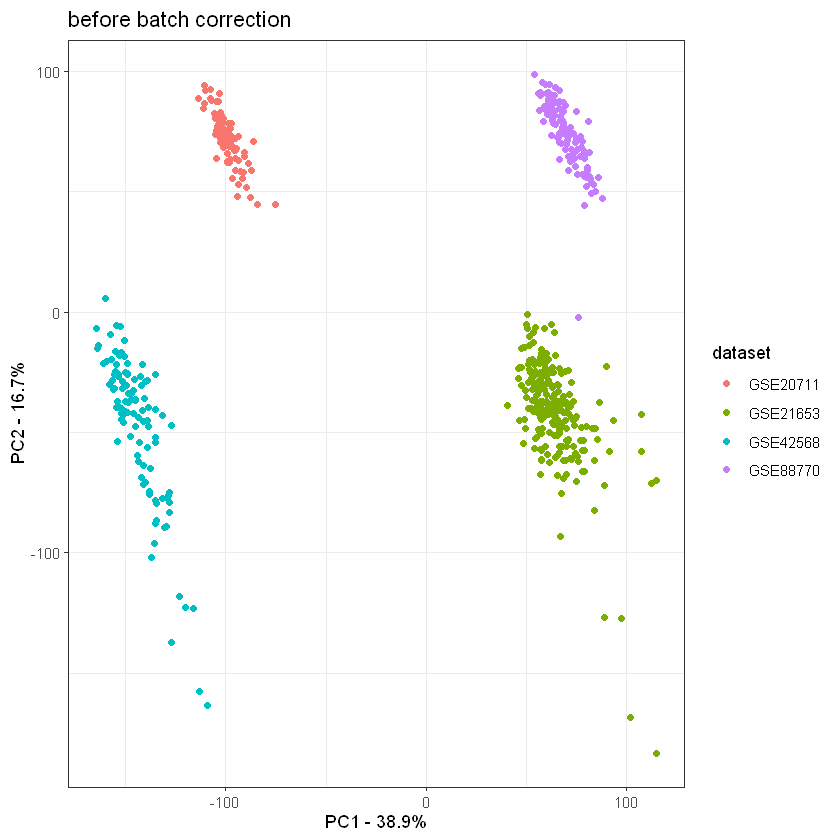

In [13]:
plot

# Batch Corrected Datasets

In [35]:
batch_combined <- prepare_batch_corrected_data(BATCH_DIR, datasets)

Loading batch-corrected datasets...

  Loaded GSE42568 - 104 samples

  Loaded GSE21653 - 241 samples

  Loaded GSE20711 - 86 samples

  Loaded GSE88770 - 117 samples

Intersecting genes across datasets...

  21655 common genes retained

Combining datasets...

  Combined: 548 total samples, 21655 genes



In [15]:
after_batch_pca <- perform_pca(batch_combined)

Running PCA...

  Done



In [16]:
batch_plot <- plot_and_save_pca(after_batch_pca, "after", RESULTS_DIR)

Plotting PCA (after batch correction)...

Saving PCA plot...

Saving 6.67 x 6.67 in image
  Saved to results/batch_correction/after_pca_scatter.png



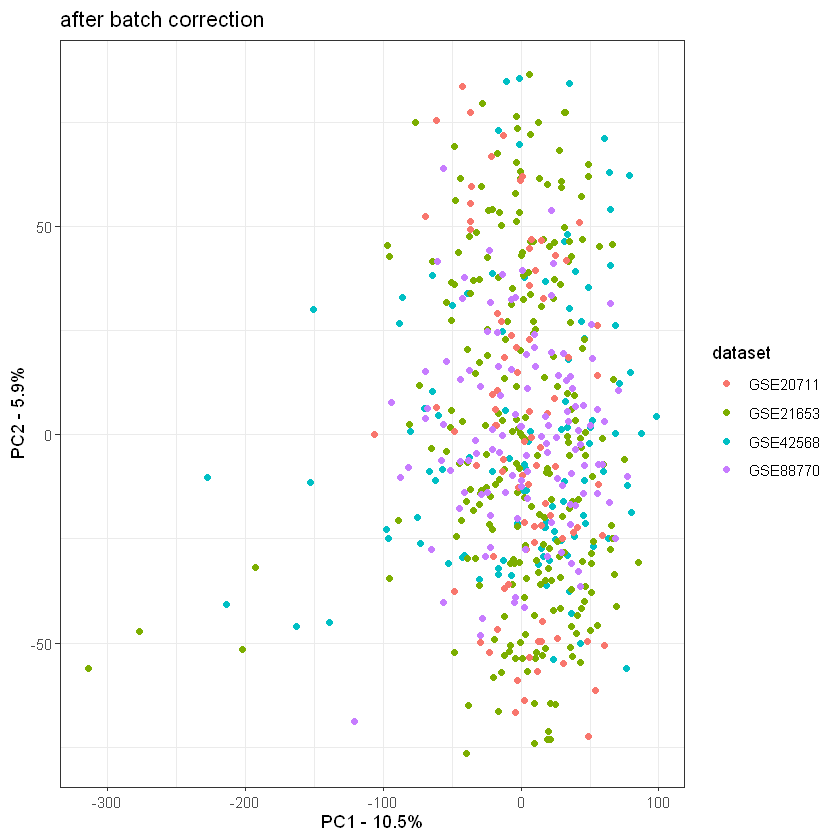

In [17]:
batch_plot

# Compute Before & After LISI

In [38]:
before_lisi <- compute_lisi(before_batch_pca)
after_lisi <- compute_lisi(after_batch_pca)

In [39]:
lisi_plot <- plot_and_save_lisi(before_lisi, after_lisi, RESULTS_DIR)

Saving LISI plot...

Saving 6.67 x 6.67 in image
  Saved to results/batch_correction/before_after_lisi_bar.png



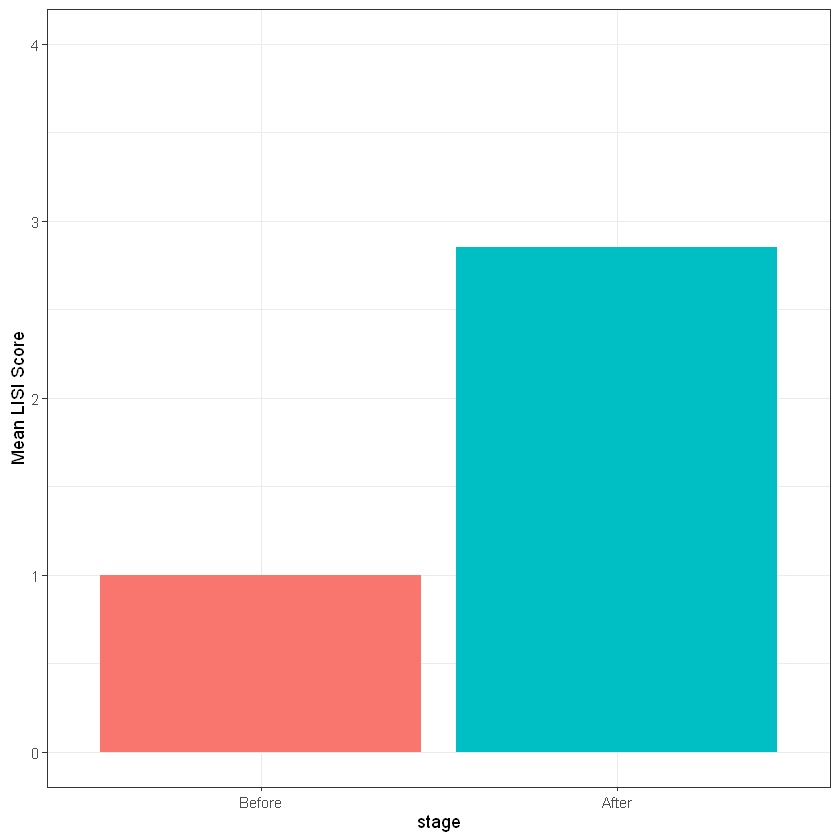

In [40]:
lisi_plot